<a href="https://colab.research.google.com/github/yibesh/DeepLearning/blob/main/Cnn_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Notebook (MNIST + CIFAR-10 + Tuning + Dropout)



This notebook demonstrates a simple Convolutional Neural Network (CNN) for image classification





## 🔹 Part 1: Baseline CNN (MNIST, handwritten digits 0–9)

In [1]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


### 🧪 Exercise 1
What does normalization do? Why do we divide by 255?

In [12]:

# 2. Load Dataset
# MNIST dataset contains 28x28 grayscale images of digits (0-9)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", train_images.shape)
print("Test data shape:", test_images.shape)


Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### 🧪 Exercise 2
How many training samples are there? What is the image size?

In [13]:
# 3. Preprocess Data

# Normalize pixel values (0–255 → 0–1)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape to include channel dimension (needed for CNN)
# (28,28) → (28,28,1)
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))



### 🧪 Exercise 3
What happens if we do NOT reshape the images? Try and see the error.

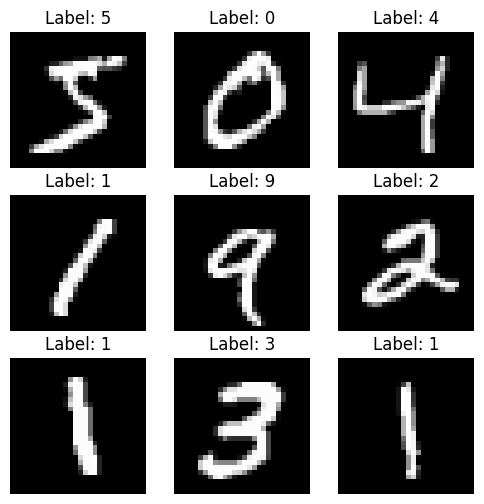

In [14]:
# 4. Visualize Sample Images

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.show()


### 🧪 Exercise 4
Display 5 different images with labels.

In [5]:
# 5. Build Model
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)), # First Convolution Layer (feature extraction)
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'), # Second Convolution Layer
    layers.MaxPooling2D((2,2)),
    layers.Flatten(), # Flatten the output (convert 2D → 1D)
    layers.Dense(64,activation='relu'), # Fully connected (Dense) layer
    layers.Dense(10,activation='softmax') # Output layer (10 classes → digits 0-9)
])
model.summary() # Show model architecture


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### 🧪 Exercise 5
- Change number of filters (32 → 16 or 64)
- Add one more Conv2D layer
- Observe changes in accuracy


In [15]:
# 6. Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


### 🧪 Exercise 6
Try a different optimizer like 'sgd'. What happens?

In [16]:
# 7. Train Model
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images,test_labels))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9945 - loss: 0.0170 - val_accuracy: 0.9924 - val_loss: 0.0296
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9963 - loss: 0.0121 - val_accuracy: 0.9903 - val_loss: 0.0351
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.9914 - val_loss: 0.0313
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9967 - loss: 0.0095 - val_accuracy: 0.9929 - val_loss: 0.0313
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.9979 - loss: 0.0063 - val_accuracy: 0.9874 - val_loss: 0.0511


### 🧪 Exercise 7
Increase epochs to 10. Does accuracy improve? Any overfitting?

In [17]:
# 8. Evaluate Model
loss, acc = model.evaluate(test_images, test_labels)
print(acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9874 - loss: 0.0511
0.9873999953269958


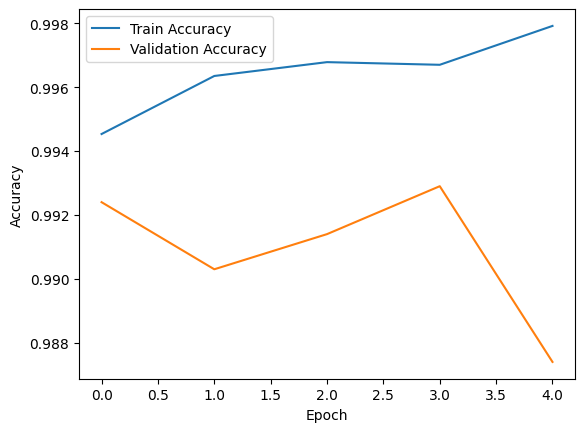

In [18]:
# 9. Plot Accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 🧪 Exercise 8
Explain the gap between training and validation accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


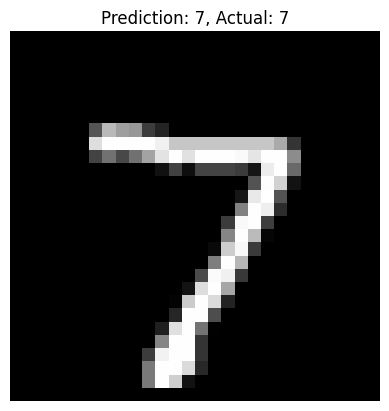

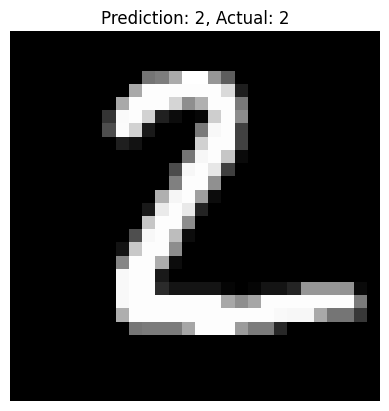

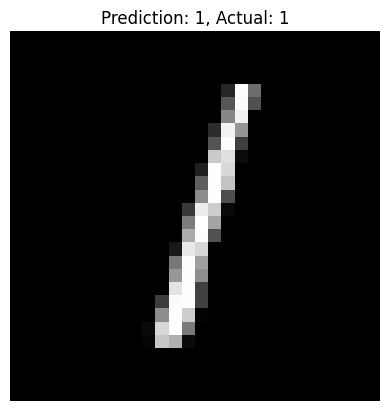

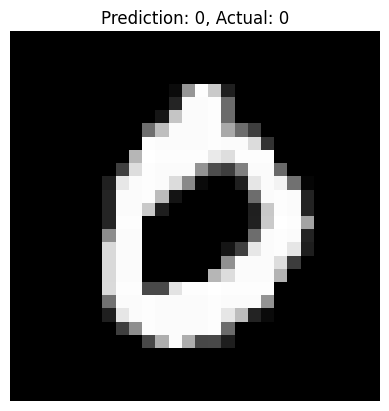

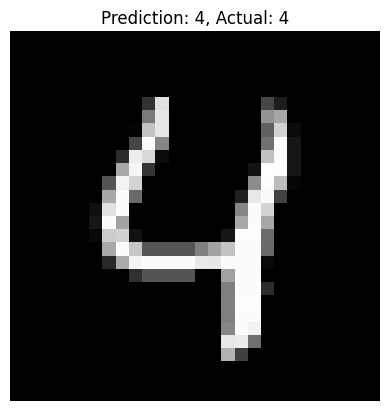

In [19]:
# 10. Prediction of test dataset
predictions = model.predict(test_images)

for i in range(5):
    plt.imshow(test_images[i].reshape(28,28), cmap='gray')
    plt.title(f"Prediction: {predictions[i].argmax()}, Actual: {test_labels[i]}")
    plt.axis('off')
    plt.show()


### 🧪 Final Challenge
Try using another dataset like Fashion MNIST.

## 🔹 Part 2: Add Dropout (Prevent Overfitting)

In [20]:
model_dropout = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])

model_dropout.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = model_dropout.fit(train_images, train_labels, epochs=3,
                                    validation_data=(test_images,test_labels))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9046 - loss: 0.3190 - val_accuracy: 0.9742 - val_loss: 0.0843
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9571 - loss: 0.1452 - val_accuracy: 0.9796 - val_loss: 0.0609
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9664 - loss: 0.1126 - val_accuracy: 0.9837 - val_loss: 0.0496


### 🧪 Exercise 9
- Compare accuracy with and without Dropout
- Try Dropout = 0.3 and 0.7
- Which works best?


## 🔹 Part 3: CNN Tuning

In [ ]:
model_tuned = models.Sequential([
    layers.Conv2D(64,(3,3),activation='relu',input_shape=(28,28,1)), # 64 filters (feature detectors),  Each filter is 3x3 in size,  Stride = 1 (moves one pixel at a time)
    layers.MaxPooling2D((2,2)),    # Pooling layer:Reduces image size by half → makes training faster and avoids overfitting. Takes the maximum value in each 2x2 region,
    layers.Conv2D(128,(3,3),activation='relu'), # 128 filters (feature detectors),  Each filter is 3x3 in size,
    layers.MaxPooling2D((2,2)),
    layers.Flatten(), #convert 2D feature maps to 1D vector for dense layers.  #Needed before feeding into Dense (fully connected) layers
    layers.Dense(128,activation='relu'), # Fully connected layer (dense): learns relationships between features. # 64 neurons
    layers.Dense(10,activation='softmax') # Output layer: 10 neurons for 10 digit classes (0–9)
])

model_tuned.compile(optimizer='adam', # Adam optimizer → adjusts learning rate automatically
                    loss='sparse_categorical_crossentropy', # Sparse categorical crossentropy → suitable for integer labels (0–9)
                    metrics=['accuracy'])

history_tuned = model_tuned.fit(train_images, train_labels, epochs=3,
                                validation_data=(test_images,test_labels))


### 🧪 Exercise 10
- Increase filters (32 → 64 → 128)
- Add more layers
- Observe training time vs accuracy


## 🔹 Part 4: Real Dataset (CIFAR-10 Color Images)

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0


In [ ]:
model_cifar = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model_cifar.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_cifar = model_cifar.fit(train_images, train_labels, epochs=5,
                                validation_data=(test_images,test_labels))


### 🧪 Exercise 11
- Why is CIFAR-10 harder than MNIST?
- Try deeper CNN
- Try data augmentation (bonus)


# 🚀 Advanced CNN Notebook (MNIST + CIFAR-10 + Tuning + Dropout)
Includes advanced student tasks.

## 🎯 Final Challenge
- Add BatchNormalization
- Use Data Augmentation

